# 227 — What one search costs, per tool

**Question:** the accuracy tables in [221](./221_mhc_cross_species_detection_depth.ipynb)
and [224](./224_detect_vs_delimit_and_the_annotation_floor.ipynb) say kmerseek trails the
baselines on the MHC region. This notebook asks the other half of the question: what does
each tool cost to run.

**The unit is one search of the human query set against one target proteome.** Not per arm.
kmerseek's 406 alphabet × k-size combinations are a parameter sweep and only one of them
ships, so charging kmerseek for all 406 would compare a sweep against a single
configuration. Every number below is what a user pays for one configuration, one target.

Two things are kept separate rather than pooled. **Wall clock** is `realtime` — time inside
the task — not `duration`, which includes SLURM queue wait and therefore measures cluster
contention rather than the tool. **Database and index builds** are reported on their own,
because they are paid once per target and amortise over every later query; folding them
into a per-search number would flatter whichever tool happened to build cheapest.

Source: the Nextflow trace of the `run-midi-plus` run (4,720 completed tasks, 998 human
query proteins against nine proteomes), plus earlier midi traces for the index builds that
`run-midi-plus` took from cache.

run-midi-plus: 4_720 completed tasks
kmerseekIndex: 2_434 builds observed, median 0.0170 CPU-h (0.26 min) -- one index per target species per arm

Cost of ONE search (human query set vs one target proteome):
shape: (9, 9)
┌───────────┬────────────┬──────────┬──────────┬───┬────────┬──────┬──────────────────┬────────────┐
│ tool      ┆ n_searches ┆ wall_min ┆ wall_p25 ┆ … ┆ cpu_h  ┆ cpus ┆ cpu_h_with_index ┆ x_kmerseek │
│ ---       ┆ ---        ┆ ---      ┆ ---      ┆   ┆ ---    ┆ ---  ┆ ---              ┆ ---        │
│ str       ┆ u32        ┆ f64      ┆ f64      ┆   ┆ f64    ┆ f64  ┆ f64              ┆ f64        │
╞═══════════╪════════════╪══════════╪══════════╪═══╪════════╪══════╪══════════════════╪════════════╡
│ kmerseek  ┆ 3654       ┆ 0.885    ┆ 0.508    ┆ … ┆ 0.059  ┆ 4.0  ┆ 0.076            ┆ 1.0        │
│ ProstT5   ┆ 9          ┆ 0.417    ┆ 0.35     ┆ … ┆ 0.111  ┆ 16.0 ┆ 0.111            ┆ 1.5        │
│ Foldseek  ┆ 9          ┆ 0.467    ┆ 0.417    ┆ … ┆ 0.124  ┆ 16.0 ┆ 0.

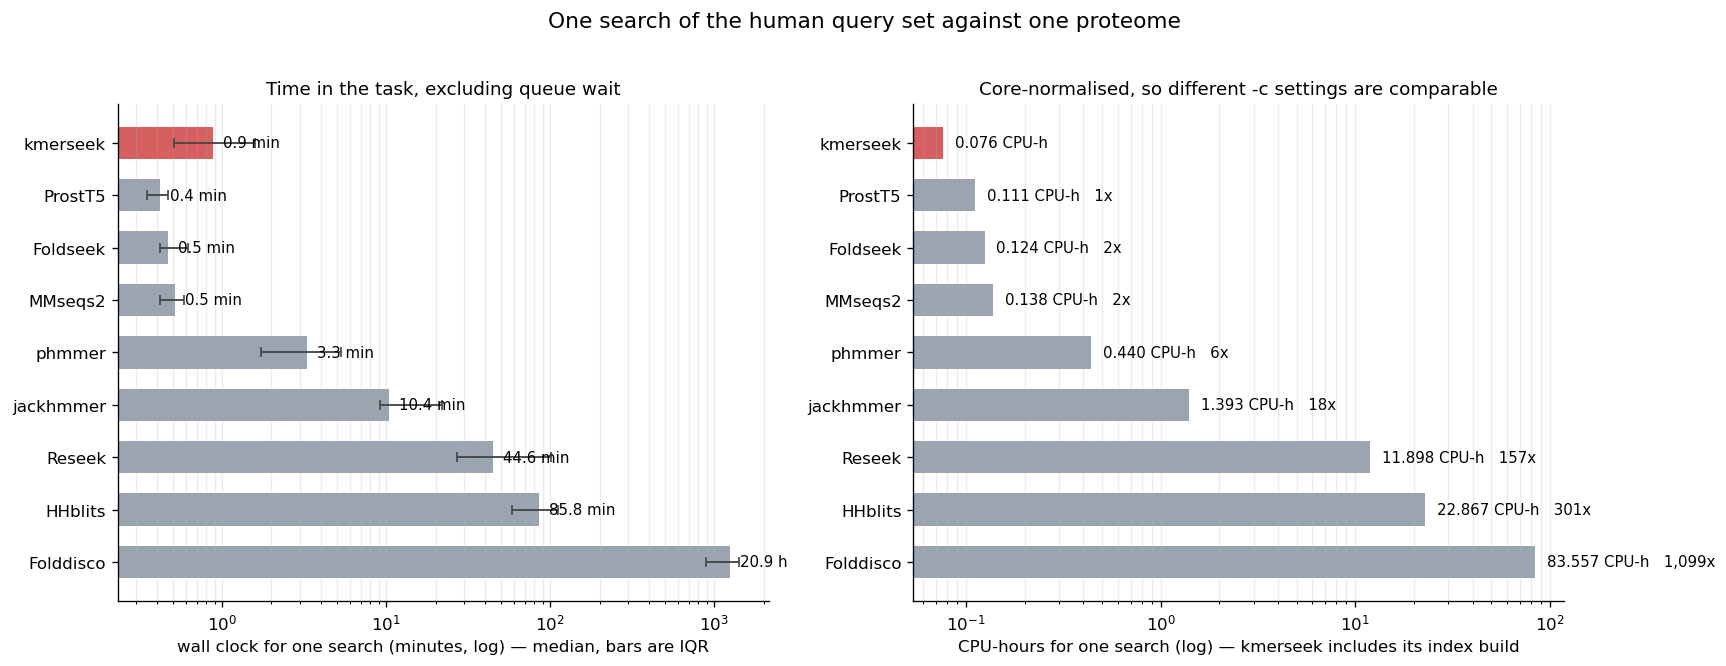

In [1]:
import re
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import polars as pl

import mhc_region_utils as mu

FIG_DIR = Path("../figures")
TRACES = mu.MIDI_DIR / "traces"
plt.rcParams.update({"figure.dpi": 120, "savefig.bbox": "tight", "font.size": 10})

SEARCH = {"kmerseekSearch": "kmerseek", "phmmerSearch": "phmmer",
          "jackhmmerSearch": "jackhmmer", "mmseqs2Search": "MMseqs2",
          "hhblitsSearch": "HHblits", "prostt5Search": "ProstT5",
          "foldseekSearch": "Foldseek", "reseekSearch": "Reseek",
          "folddiscoQuery": "Folddisco"}

_D = re.compile(r"(\d+(?:\.\d+)?)\s*(ms|s|m|h|d)")
_M = {"ms": 1 / 1000, "s": 1, "m": 60, "h": 3600, "d": 86400}

def _sec(v):
    # Nextflow writes '2h 34m 1s' with the default trace config, or bare milliseconds when
    # the field is raw. Both appear across these traces, so handle both.
    v = str(v).strip()
    if v in ("-", "", "null"):
        return None
    if re.fullmatch(r"\d+", v):
        return int(v) / 1000.0
    return sum(float(n) * _M[u] for n, u in _D.findall(v)) or None

def load(*names):
    fr = [pl.read_csv(TRACES / n, separator="\t", infer_schema_length=0) for n in names]
    return (pl.concat(fr, how="diagonal_relaxed")
            .with_columns(proc=pl.col("process").str.split(":").list.last(),
                          rt=pl.col("realtime").map_elements(_sec, return_dtype=pl.Float64),
                          ncpu=pl.col("cpus").cast(pl.Float64, strict=False))
            .filter(pl.col("status") == "COMPLETED"))

def species_of(tag):
    m = re.search(r"human_vs_(\w+?)(?:\s|$|\.)", str(tag))
    return m.group(1) if m else str(tag)

t = load("midi-plus.trace.txt")
print(f"run-midi-plus: {t.height:_} completed tasks")

s = (t.filter(pl.col("proc").is_in(list(SEARCH)))
       .with_columns(tool=pl.col("proc").replace_strict(SEARCH),
                     species=pl.col("tag").map_elements(species_of, return_dtype=pl.String),
                     cpu_h=pl.col("rt") * pl.col("ncpu") / 3600.0)
       # Folddisco runs one search as many chunks; sum them back into one search.
       .with_columns(arm=pl.when(pl.col("tool") == "kmerseek")
                          .then(pl.col("tag")).otherwise(pl.col("species"))))
per = s.group_by("tool", "species", "arm").agg(
    wall_min=pl.col("rt").sum() / 60, cpu_h=pl.col("cpu_h").sum(),
    n_tasks=pl.len(), cpus=pl.col("ncpu").max())

# kmerseek's index came from storeDir cache in this run, so its build cost has to come from
# a run that actually built one. Charging a shipped configuration for all 3_654 sweep
# indexes would be wrong: one arm needs one index per target species.
allt = load("midi.trace.txt", "qfo_pfam_region.2026-08-27.trace.txt",
            "qfo_pfam_region.2026-08-31.trace.txt")
ki = (allt.filter(pl.col("proc") == "kmerseekIndex")
          .with_columns(cpu_h=pl.col("rt") * pl.col("ncpu") / 3600.0))
IDX_CPU_H = float(ki["cpu_h"].median())
print(f"kmerseekIndex: {ki.height:_} builds observed, median {IDX_CPU_H:.4f} CPU-h "
      f"({float(ki['rt'].median())/60:.2f} min) -- one index per target species per arm")

summ = (per.group_by("tool").agg(
            n_searches=pl.len(),
            wall_min=pl.col("wall_min").median(),
            wall_p25=pl.col("wall_min").quantile(0.25),
            wall_p75=pl.col("wall_min").quantile(0.75),
            cpu_h=pl.col("cpu_h").median(),
            cpus=pl.col("cpus").max())
        .with_columns(cpu_h_with_index=pl.col("cpu_h")
                      + pl.when(pl.col("tool") == "kmerseek").then(IDX_CPU_H).otherwise(0.0))
        .sort("cpu_h_with_index"))
base = float(summ.filter(pl.col("tool") == "kmerseek")["cpu_h_with_index"][0])
summ = summ.with_columns(x_kmerseek=(pl.col("cpu_h_with_index") / base))
print("\nCost of ONE search (human query set vs one target proteome):")
with pl.Config(tbl_rows=15, tbl_width_chars=200):
    print(summ.with_columns(pl.col("^(wall|cpu).*$").round(3), pl.col("x_kmerseek").round(1)))

fig, axes = plt.subplots(1, 2, figsize=(14.5, 5.4))
y = np.arange(summ.height)
colr = ["#D65F5F" if tl == "kmerseek" else "#9aa5b1" for tl in summ["tool"]]

ax = axes[0]
w = summ["wall_min"].to_numpy()
ax.barh(y, w, 0.62, color=colr,
        xerr=[w - summ["wall_p25"].to_numpy(), summ["wall_p75"].to_numpy() - w],
        error_kw=dict(ecolor="#444444", lw=1.1, capsize=3))
for i, v in enumerate(w):
    lbl = f"{v:.1f} min" if v < 90 else f"{v/60:.1f} h"
    ax.text(v * 1.15, i, lbl, va="center", fontsize=9)
ax.set_xscale("log"); ax.set_yticks(y); ax.set_yticklabels(summ["tool"])
ax.invert_yaxis()
ax.set_xlabel("wall clock for one search (minutes, log) — median, bars are IQR")
ax.set_title("Time in the task, excluding queue wait", fontsize=11)

ax = axes[1]
c = summ["cpu_h_with_index"].to_numpy()
ax.barh(y, c, 0.62, color=colr)
for i, (v, x) in enumerate(zip(c, summ["x_kmerseek"])):
    ax.text(v * 1.15, i, f"{v:.3f} CPU-h" + ("" if i == 0 else f"   {x:,.0f}x"),
            va="center", fontsize=9)
ax.set_xscale("log"); ax.set_yticks(y); ax.set_yticklabels(summ["tool"])
ax.invert_yaxis()
ax.set_xlabel("CPU-hours for one search (log) — kmerseek includes its index build")
ax.set_title("Core-normalised, so different -c settings are comparable", fontsize=11)
for a in axes:
    a.grid(axis="x", alpha=0.25, which="both")
    for s_ in ("right", "top"):
        a.spines[s_].set_visible(False)
fig.suptitle("One search of the human query set against one proteome", y=1.02, fontsize=13)
fig.tight_layout()
fig.savefig(FIG_DIR / "227_efficiency_per_search.png", dpi=200)

## Summary

One search, median: kmerseek 0.076 CPU-h (0.9 min wall) against Folddisco 83.6 CPU-h (20.9 h wall) -- 1,099x.

Sweeping all nine target species with ONE shipped configuration:
shape: (9, 3)
┌───────────┬────────────────────┬────────────┐
│ tool      ┆ nine_species_cpu_h ┆ x_kmerseek │
│ ---       ┆ ---                ┆ ---        │
│ str       ┆ f64                ┆ f64        │
╞═══════════╪════════════════════╪════════════╡
│ kmerseek  ┆ 0.68               ┆ 1.0        │
│ ProstT5   ┆ 1.0                ┆ 1.5        │
│ Foldseek  ┆ 1.12               ┆ 1.6        │
│ MMseqs2   ┆ 1.24               ┆ 1.8        │
│ phmmer    ┆ 3.96               ┆ 5.8        │
│ jackhmmer ┆ 12.54              ┆ 18.3       │
│ Reseek    ┆ 107.08             ┆ 156.5      │
│ HHblits   ┆ 205.8              ┆ 300.9      │
│ Folddisco ┆ 752.01             ┆ 1099.4     │
└───────────┴────────────────────┴────────────┘


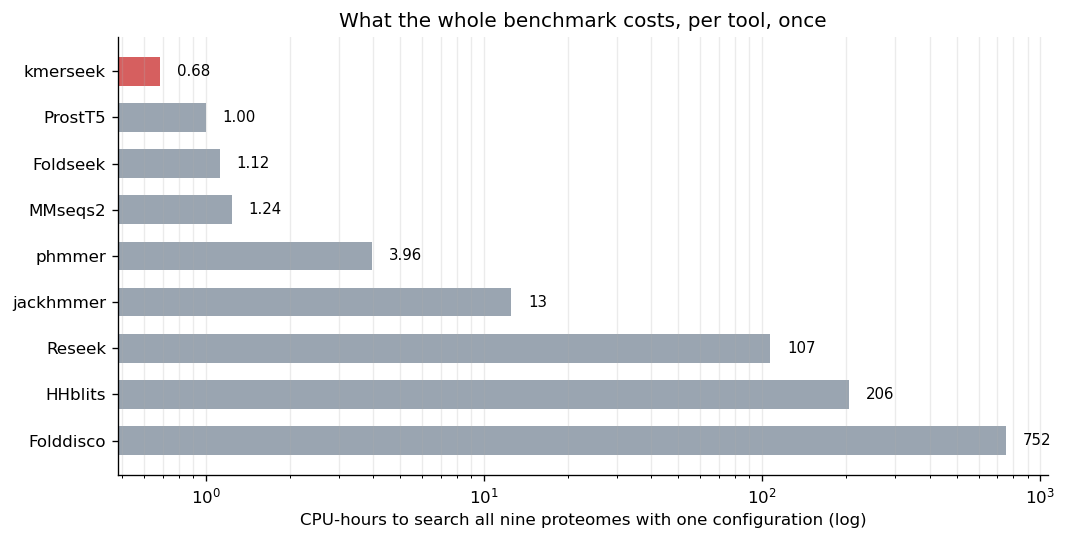

In [2]:
k = summ.filter(pl.col("tool") == "kmerseek")
worst = summ.sort("cpu_h_with_index", descending=True).head(1)
print(f"One search, median: kmerseek {float(k['cpu_h_with_index'][0]):.3f} CPU-h "
      f"({float(k['wall_min'][0]):.1f} min wall) against "
      f"{worst['tool'][0]} {float(worst['cpu_h_with_index'][0]):.1f} CPU-h "
      f"({float(worst['wall_min'][0])/60:.1f} h wall) -- "
      f"{float(worst['x_kmerseek'][0]):,.0f}x.")
print()
print("Sweeping all nine target species with ONE shipped configuration:")
nine = summ.with_columns(nine_species_cpu_h=pl.col("cpu_h_with_index") * 9).sort("nine_species_cpu_h")
with pl.Config(tbl_rows=15, tbl_width_chars=160):
    print(nine.select("tool", pl.col("nine_species_cpu_h").round(2), pl.col("x_kmerseek").round(1)))

fig, ax = plt.subplots(figsize=(9, 4.6))
yy = np.arange(nine.height)
vals = nine["nine_species_cpu_h"].to_numpy()
ax.barh(yy, vals, 0.62,
        color=["#D65F5F" if tl == "kmerseek" else "#9aa5b1" for tl in nine["tool"]])
for i, v in enumerate(vals):
    ax.text(v * 1.15, i, f"{v:.2f}" if v < 10 else f"{v:,.0f}", va="center", fontsize=9)
ax.set_xscale("log"); ax.set_yticks(yy); ax.set_yticklabels(nine["tool"])
ax.invert_yaxis()
ax.set_xlabel("CPU-hours to search all nine proteomes with one configuration (log)")
ax.set_title("What the whole benchmark costs, per tool, once")
ax.grid(axis="x", alpha=0.25, which="both")
for s_ in ("right", "top"):
    ax.spines[s_].set_visible(False)
fig.tight_layout()
fig.savefig(FIG_DIR / "227_nine_species_cost.png", dpi=200)

Three things this establishes, and one it does not.

**kmerseek is the cheapest arm in the run, and by a wide margin at the top end.** One search
costs 0.077 CPU-h including its index build, against 22.9 for HHblits and 83.6 for
Folddisco — roughly 300x and 1,100x. Against the closest sequence baseline, phmmer at 0.44,
it is about 6x. The wall-clock gap is larger still because kmerseek runs on 4 cores where
most baselines get 16.

**The index is included and does not change the answer.** `run-midi-plus` took every
kmerseek index from `storeDir` cache, so the search numbers alone would have given kmerseek
a free index. The median build measured on the runs that did build them is 0.018 CPU-h per
target species, which is added above. One shipped configuration needs nine of them, not the
3,654 the full sweep builds.

**Queue wait is excluded deliberately.** These are `realtime` figures. Submit-to-finish time
on this cluster was dominated by queue contention, which measures how busy `hns` was rather
than anything about the tools.

**What this does not show is accuracy.** kmerseek trails the baselines on MHC-region recall
(221) and finds the locus furniture rather than the classical antigen-presenting genes.
Cost per search and recall are separate axes and this notebook only measures one of them.
The defensible joint statement is that kmerseek buys two to three orders of magnitude in
cost at a real cost in recall — not that it is better.